# Figure 6

In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection


pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


## Figure 6a-d
Ghost plane in coupled theta neuron model from Augustsson & Martens 2024 (https://doi.org/10.1063/5.0226338)

**Figure 6a**

GhostID: Trajectory does not leave U_eps - stopping ghostID.
Number of ghosts identified: 0


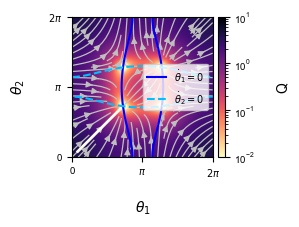

In [10]:
######################
# Before bifurcation #
######################

# set parameters
n = -0.25; K = 0.1; pS = np.pi
parameters_theta =  [n,K,pS]

# simulate trajectory 
dt = 0.005
timesteps = np.linspace(0,30,int(30/dt))
sol = solve_ivp(mod.coupledThetaNeurons, (0, 30), [0.25,0.25],
                    t_eval=timesteps, args=(parameters_theta,),method='RK45',rtol=1e-4,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.coupledThetaNeurons,parameters_theta,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #
print("Number of ghosts identified:",len(ghostSeq))


#  plot phase space
xmin=0;xmax=2*np.pi
ymin=0;ymax=2*np.pi

Ng=200
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.coupledThetaNeurons,parameters_theta,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(5*inCm,7*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.coupledThetaNeurons(t,z,parameters_theta)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U, V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-2 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.coupledThetaNeurons(0,jnp.array([Xg,Yg]),parameters_theta)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot\theta_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot\theta_2 = 0$')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,np.pi,2*np.pi]); ax.set_yticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.legend(fontsize=7)
plt.savefig("Figure6a1.svg")
plt.show()


**Figure 6b**

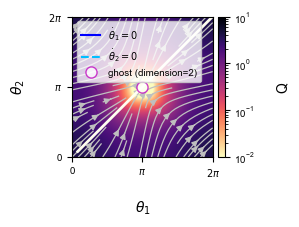

In [ ]:
######################
# After bifurcation #
######################

# set parameters
n = 0.01; K = 0.1; pS = np.pi
parameters_theta =  [n,K,pS]

# simulate trajectory 
dt = 0.005
timesteps = np.linspace(0,30,int(30/dt))
sol = solve_ivp(mod.coupledThetaNeurons, (0, 30), [0.25,0.25],
                    t_eval=timesteps, args=(parameters_theta,),method='RK45',rtol=1e-4,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.coupledThetaNeurons,parameters_theta,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

#  plot phase space
xmin=0;xmax=2*np.pi
ymin=0;ymax=2*np.pi

Ng=200
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.coupledThetaNeurons,parameters_theta,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(5*inCm,7*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.coupledThetaNeurons(t,z,parameters_theta)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U, V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-2 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.coupledThetaNeurons(0,jnp.array([Xg,Yg]),parameters_theta)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot\theta_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot\theta_2 = 0$')

# plot ghost
gx,gy = ghostSeq[0]["position"]
ax.plot(gx,gy,'ow',mec='m',markersize=8,alpha=0.75,label=f'ghost (dimension={ghostSeq[0]["dimension"]})')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,np.pi,2*np.pi]); ax.set_yticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.legend(fontsize=7)
plt.savefig("Figure6a2.svg")
plt.show()


Plot control outputs from ghostID (only for verification)

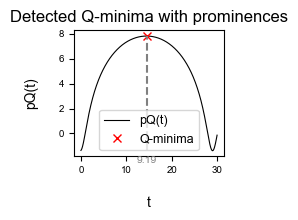

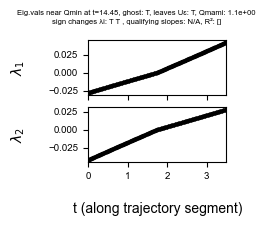

In [5]:
# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(5*inCm,6*inCm)
plt.figure(fig)
plt.show()

# # eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,5*inCm)
axes[0].set_xlim(0,3.5)
axes[1].set_xlim(0,3.5)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.show()

Track ghost in parameter space and plot in bifurcation diagram

In [6]:
ghost_start = ghostSeq[0]

positions_ghosts, paramVals, ghostSeqs =  gid.track_ghost_branch(ghostSeq[0], mod.coupledThetaNeurons, parameters_theta, 
                                                                 0, 20, 0.05, 25, dt, delta=0.35, icStep=0.2,# mode="closest", 
                                                                 epsilon_gid=0.2,evLimit=0.1, peak_kwargs={"prominence":0},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",qmin_glob_options={"seed":9,"n_samples":150},qmin_loc_method=None) #7


Progress: 100.00% | param value=1.01000: 100%|██████████| 21/21 [00:56<00:00,  2.67s/it]


Calculating mutual information between system response and inputs

**Figure 6c+d**

-0.000674574


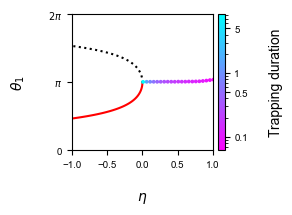

In [ ]:
# load bifurcation data from XPPAUT for plotting
with open("Fig6_theta_bifurcation.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []

for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))

dat_theta_cpld = np.asarray(data)

fig = plt.figure(figsize=(5*inCm,4.5*inCm))

ax1 = fig.add_subplot()

#plot SNs from XPPAUT
id_SN = 0
id_SN_end = 61
ax1.plot(dat_theta_cpld[id_SN:id_SN_end,3],dat_theta_cpld[id_SN:id_SN_end,6],'-r')
id_us_end = 117
ax1.plot(dat_theta_cpld[id_SN_end:id_us_end,3],dat_theta_cpld[id_SN_end:id_us_end,6],':k')
print(max(dat_theta_cpld[id_SN:id_SN_end,3]))
trapping_durations = [ghostSeqs[i]["duration"] for i in range(len(ghostSeqs))]

ax1.plot(paramVals, positions_ghosts[:,0],'-',color='grey', lw=0.5, zorder=1)
sc = ax1.scatter(paramVals, positions_ghosts[:,0], c=trapping_durations, marker='o', s=3, norm=LogNorm(), cmap='cool_r', zorder=2)

ax1.set_ylabel(r"$\theta_1$")
ax1.set_xlabel(r"$\eta$")
ax1.set_ylim(0,2*np.pi)
ax1.set_xlim(-1,1)
ax1.set_yticks([0,np.pi,2*np.pi])
ax1.set_yticklabels(['0',r'$\pi$',r'$2\pi$']);

# Add colorbar
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = plt.colorbar(sc, cax=cax, label='Trapping duration')
cb.set_ticks([1, 0.1, 0.5, 5])
cb.set_ticklabels(['1', '0.1', '0.5', '5'])

plt.savefig("Figure6b.svg")


In [2]:
np.linspace(-1,1,26)

array([-1.  , -0.92, -0.84, -0.76, -0.68, -0.6 , -0.52, -0.44, -0.36,
       -0.28, -0.2 , -0.12, -0.04,  0.04,  0.12,  0.2 ,  0.28,  0.36,
        0.44,  0.52,  0.6 ,  0.68,  0.76,  0.84,  0.92,  1.  ])

In [3]:
import gc

n = 26 #51
eta1_range = np.linspace(-1,1,n)
eta2_range = np.linspace(-1,1,n)
dimensions = np.ones((len(eta1_range),len(eta2_range)))*-1

try:
    dimensions = np.load(f"thetaNeurons_ghostDimensions_{n}.npy")
    print("Existing data file found, resuming computation")
except:
    print("No existing data file found, starting new computation")

for i in range(len(eta1_range)):
    for j in range(len(eta2_range)):
        if dimensions[i,j] == -1:
            if not (eta2_range[j]<-0.15 and eta1_range[i]<-0.15):
                
                n1 = eta1_range[i]
                n2 =  eta2_range[j]
                print("eta1: ", n1, " eta2: ", n2)
                K = 0.1
                pS = np.pi
                parameters_theta_nonident =  [n1,n2,K,pS]

                # simulate trajectory 
                t_end = 75 if (n1<0 or n2<0) else 275
                dt = 0.002 if (n1>0.15 or n2>0.15) else 0.001
                n_samples = 30 if (n1<0 or n2<0) else 40
            
                result_pss = gid.ghostID_phaseSpaceSample(mod.coupledThetaNeurons_nonident,parameters_theta_nonident,0,t_end,dt,
                                                [np.linspace(0,2*np.pi,20),np.linspace(0,2*np.pi,20)],n_samples=n_samples,seed=1,rtol=1e-5,atol=1e-6,
                                                peak_kwargs={"prominence":0,"width":0},display_warnings=False,epsilon_gid=0.2,epsilon_SN_ghosts=0.5,epsilon_unify=0.5)
            
        
                dims = [g["dimension"] for seq in result_pss for g in seq] if len(result_pss)>0 else []
                
                dimensions[i,j] = max(dims) if len(dims)>0 else 0

                np.save(f"thetaNeurons_ghostDimensions_{n}.npy", dimensions)

                # Clear variables to free memory
                del n1, n2, parameters_theta_nonident, result_pss, dims
                gc.collect()


   

Existing data file found, resuming computation
eta1:  0.9199999999999999  eta2:  0.6000000000000001
[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs:   0%|          | 0/40 [00:00<?, ?IC/s]

Processing ICs: 100%|██████████| 40/40 [02:00<00:00,  3.02s/IC]


eta1:  0.9199999999999999  eta2:  0.6799999999999999
[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 40/40 [01:57<00:00,  2.94s/IC]


...

Processing ICs: 100%|██████████| 40/40 [02:00<00:00,  3.02s/IC]


eta1:  1.0  eta2:  0.9199999999999999
[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 40/40 [01:54<00:00,  2.85s/IC]


eta1:  1.0  eta2:  1.0
[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 40/40 [01:53<00:00,  2.85s/IC]


Ghost Bifurcation

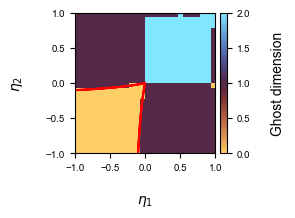

In [10]:
# load bifurcation data from XPPAUT for plotting
with open("thetaNonident_2D_eta1branch.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []

for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))

dat_eta1_branch = np.asarray(data)

with open("thetaNonident_2D_eta1branch.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []

for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))

dat_eta2_branch = np.asarray(data)

try:
    dimensions = np.load("thetaNeurons_ghostDimensions_26.npy")
    for i in range(dimensions.shape[0]):
       for j in range(dimensions.shape[0]): 
           if dimensions[i,j] == -1: dimensions[i,j]=0
    # dimensions[np.where(dimensions==-1)[0]]=0
except:
    print("No existing data file found.")

# plt.figure(figsize=(4.5*inCm,4.5*inCm))
plt.figure(figsize=(5*inCm,7*inCm))
im = plt.imshow(dimensions.T, origin='lower', extent=[-1,1,-1,1], cmap='managua', aspect='equal')

#plot SNs from XPPAUT
id_SN = 85
plt.plot(dat_eta1_branch[id_SN:,3],dat_eta1_branch[id_SN:,4],'-r')
id_SN = 85
plt.plot(dat_eta2_branch[id_SN:,4],dat_eta2_branch[id_SN:,3],'-r')

plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.yticks([-1, -0.5, 0, 0.5, 1])
plt.ylim(-1,1)
plt.xlim(-1,1)
plt.xlabel(r'$\eta_1$')   
plt.ylabel(r'$\eta_2$')

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Ghost dimension")

plt.savefig("Figure6c.svg")


-0.198644


eigenvalues for first ghost: [-0.82065535+0.j  0.07588474+0.j]
eigenvalues for second ghost: [0.77692246+0.j 0.039008  +0.j]


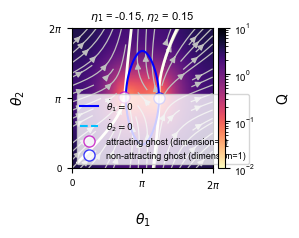

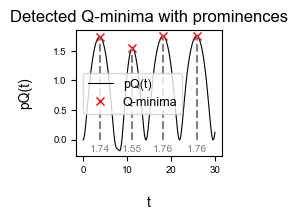

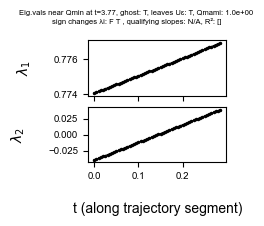

eigenvalues for first ghost: [ 0.0758847 +0.j -0.82065535+0.j]
eigenvalues for second ghost: [0.03900802+0.j 0.77692246+0.j]


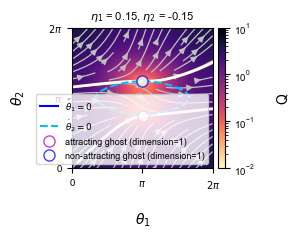

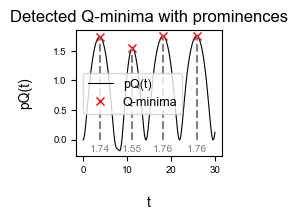

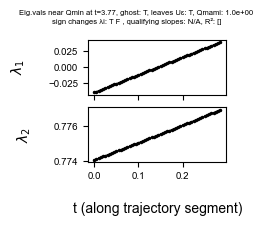

In [4]:
######################
# After bifurcation #
######################

eta1_range = [-0.15,0.15]
eta2_range = [0.15,-0.15]

for i in range(2):

    n1 = eta1_range[i]
    n2 = eta2_range[i]
        
    # set parameters
    K = 0.1; pS = np.pi
    parameters_theta_nonident =  [n1,n2,K,pS]

    # attracting ghost

    # simulate trajectory 
    dt = 0.005
    timesteps = np.linspace(0,30,int(30/dt))
    sol = solve_ivp(mod.coupledThetaNeurons_nonident, (0, 30), [0.25,0.25],
                        t_eval=timesteps, args=(parameters_theta_nonident,),method='RK45',rtol=1e-4,atol=1e-6)

    # run ghostID
    Trj=sol.y.T
    ghostSeq, _ = gid.ghostID(mod.coupledThetaNeurons_nonident,parameters_theta_nonident,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

    # non-attracting ghost
    
    if i==0:
          IC = [np.pi+np.pi/6.5,0]
    else:
          IC = [0,np.pi+np.pi/6.5]

    # simulate trajectory 
    dt = 0.005
    timesteps = np.linspace(0,30,int(30/dt))
    sol_ = solve_ivp(mod.coupledThetaNeurons_nonident, (0, 30), IC,
                        t_eval=timesteps, args=(parameters_theta_nonident,),method='RK45',rtol=1e-4,atol=1e-6)

    # run ghostID
    Trj=sol_.y.T
    ghostSeq_, ctrlPlots = gid.ghostID(mod.coupledThetaNeurons_nonident,parameters_theta_nonident,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #



    #  plot phase space
    xmin=0;xmax=2*np.pi
    ymin=0;ymax=2*np.pi

    Ng=100
    x_range=np.linspace(xmin,xmax,Ng)
    y_range=np.linspace(ymin,ymax,Ng)
    grid_ss = np.meshgrid(x_range, y_range)
    Xg,Yg=grid_ss

    Q, coords = gid.qOnGrid(mod.coupledThetaNeurons_nonident,parameters_theta_nonident,coords=[x_range,y_range], jit=True)

    plt.figure(figsize=(5*inCm,7*inCm))
    ax = plt.gca()

    def flow_model(t,z): 
            return mod.coupledThetaNeurons_nonident(t,z,parameters_theta_nonident)
    U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

    ax.streamplot(
        Xg, Yg,
        U, V,
        density=0.6,
        color=[0.75, 0.75, 0.75, 1],
        arrowsize=0.9,
        linewidth=0.9)

    # plot trajectories
    ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)
    ax.plot(sol_.y[0],sol_.y[1],'-',color='ivory',lw=2)

    # plot Q-value
    vmin = 1e-2 # Define log scale range 
    vmax = 10 # Avoid zero or negative values 
    im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

    # nullclines
    f1,f2 = mod.coupledThetaNeurons_nonident(0,jnp.array([Xg,Yg]),parameters_theta_nonident)
    ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
    ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
    ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot\theta_1 = 0$')
    ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot\theta_2 = 0$')

    # plot ghosts
    gx,gy = ghostSeq[0]["position"]
    print("eigenvalues for first ghost:",ghostSeq[0]["eigenvalues_qmin"])
    ax.plot(gx,gy,'ow',mec='m',markersize=8,alpha=0.75,label=f'attracting ghost (dimension={ghostSeq[0]["dimension"]})')
    print("eigenvalues for second ghost:",ghostSeq_[0]["eigenvalues_qmin"])
    gx,gy = ghostSeq_[0]["position"]
    ax.plot(gx,gy,'ow',mec='b',markersize=8,alpha=0.75,label=f'non-attracting ghost (dimension={ghostSeq[0]["dimension"]})')
    
    #labels, limits, legend
    plt.title(f"$\\eta_1$ = {n1}, $\\eta_2$ = {n2}",fontsize=8)
    ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$")
    ax.set_xlim(xmin,xmax); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0',r'$\pi$',r'$2\pi$'])
    ax.set_ylim(ymin,ymax); ax.set_yticks([0,np.pi,2*np.pi]); ax.set_yticklabels(['0',r'$\pi$',r'$2\pi$'])
    
    # add colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax,label="Q")

    ax.legend(fontsize=6.5)
    plt.savefig(f"Figure6d{i+1}.svg")
    plt.show()

    # Control plots for non-attracting ghosts

    # pQ timeseries and Q-minima
    fig, ax = ctrlPlots[0]
    fig.set_size_inches(5*inCm,6*inCm)
    plt.figure(fig)
    plt.show()

      # # eigenvalues across trajectories
    fig, axes = ctrlPlots[1]
    suptxt = fig._suptitle.get_text()
    fig.suptitle(suptxt,fontsize=5.5)
    fig.set_size_inches(5*inCm,5*inCm)
    axes[0].set_ylabel('$\\lambda_1$')
    axes[1].set_ylabel('$\\lambda_2$')
    axes[1].set_xlabel('t (along trajectory segment)')
    plt.figure(fig)
    plt.show()
    

